# Felix

## Carga de Datos

In [6]:
# 1. Manipulación y Procesamiento de Datos
import pandas as pd
import numpy as np
from scipy import stats

# 2. Preprocesamiento y Transformación de Variables (ML)
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 3. Modelado y Algoritmos (Machine Learning y Regresión)
from sklearn.ensemble import IsolationForest     
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 4. Visualización de Datos Estática (Informes y Documentación)
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Visualización de Datos Interactiva y Modelos 3D (Presentación en clase)
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

# Configuración por defecto para que Plotly abra los gráficos 3D en tu navegador
pio.renderers.default = "browser"

# 1. Carga del dataset
df = pd.read_csv(r'data\train.csv')
# 2. Visualizar las primeras 5 filas
print("--- Primeras filas del dataset ---")
display(df.head())

# 3. Inspección de tipos de datos y valores no nulos
print("\n--- Información general del DataFrame ---")
df.info()

--- Primeras filas del dataset ---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



--- Información general del DataFrame ---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 

### Valores Nulos

In [7]:
valores_nulos = df.isnull().sum()
columnas_con_nulos = valores_nulos[valores_nulos > 0]
columnas_con_nulos_ordenados = columnas_con_nulos.sort_values(ascending=False)
porcentaje_nulos = (columnas_con_nulos_ordenados / len(df)) * 100
tabla_nulos = pd.DataFrame({
    'Total Nulos': columnas_con_nulos_ordenados,
    'Porcentaje': porcentaje_nulos.round(2)
})
print('Columnas con datos faltantes detectadas')
display(tabla_nulos)

Columnas con datos faltantes detectadas


,Total Nulos,Porcentaje
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


## Normalización y duplicados

In [8]:
# Comprobar los valores únicos exactos de las columnas categóricas reales
print("Valores únicos en 'MSZoning' (Zonificación):")
print(df['MSZoning'].unique())

print("\nValores únicos en 'Street' (Tipo de calle):")
print(df['Street'].unique())

print("\nValores únicos en 'LotShape' (Forma del terreno):")
print(df['LotShape'].unique())

Valores únicos en 'MSZoning' (Zonificación):
<ArrowStringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str

Valores únicos en 'Street' (Tipo de calle):
<ArrowStringArray>
['Pave', 'Grvl']
Length: 2, dtype: str

Valores únicos en 'LotShape' (Forma del terreno):
<ArrowStringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str


In [9]:
# Variables categóricas clave del nuevo dataset de viviendas
print("Valores únicos en 'MSZoning' (Clasificación de la zona):")
print(df['MSZoning'].unique())

print("\nValores únicos en 'Neighborhood' (Barrios disponibles):")
print(df['Neighborhood'].unique())

print("\nValores únicos en 'SaleCondition' (Condición de la venta):")
print(df['SaleCondition'].unique())

print("\nValores únicos en 'KitchenQual' (Calidad de la cocina):")
print(df['KitchenQual'].unique())

Valores únicos en 'MSZoning' (Clasificación de la zona):
<ArrowStringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str

Valores únicos en 'Neighborhood' (Barrios disponibles):
<ArrowStringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str

Valores únicos en 'SaleCondition' (Condición de la venta):
<ArrowStringArray>
['Normal', 'Abnorml', 'Partial', 'AdjLand', 'Alloca', 'Family']
Length: 6, dtype: str

Valores únicos en 'KitchenQual' (Calidad de la cocina):
<ArrowStringArray>
['Gd', 'TA', 'Ex', 'Fa']
Length: 4, dtype: str


In [10]:
# GUARDAMOS EL DATASET LIMPIO (Aquí nace tu 'clean_train.csv')
df.to_csv('clean_train.csv', index=False)
print("✨ ¡Archivo 'clean_train.csv' generado y guardado con éxito! ✨\n")

✨ ¡Archivo 'clean_train.csv' generado y guardado con éxito! ✨



In [11]:
# ==========================================
# STEP 1: CARGA DEL DATASET LIMPIO
# ==========================================
# Separamos la variable objetivo para no alterar la detección
X = df.drop(columns=['depression_label'], errors='ignore')

categorical_cols = ['gender', 'platform_usage', 'social_interaction_level']
numerical_cols = [col for col in X.columns if col not in categorical_cols]



In [12]:
# STEP 1: TRATAMIENTO DE NULOS REAL DE TU DATASET Y GENERACIÓN DE 'clean_train.csv'
df_clean = df.copy()

# Separamos automáticas numéricas y categóricas para la imputación
categorical_cols_init = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols_init = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 1. Imputamos categóricas con la Moda (Valor más frecuente)
for col in categorical_cols_init:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 2. Imputamos numéricas con la Mediana (Evita distorsión por extremos)
for col in numerical_cols_init:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 3. Guardamos el dataset verdaderamente limpio
df_clean.to_csv('clean_train.csv', index=False)
print("✨ ¡Archivo 'clean_train.csv' generado, imputado y guardado con éxito! ✨")




C:\Users\felix\AppData\Local\Temp\ipykernel_11092\1556833944.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_init = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()


✨ ¡Archivo 'clean_train.csv' generado, imputado y guardado con éxito! ✨


In [13]:
# STEP 2: PREPARACIÓN DINÁMICA DE VARIABLES (Evita el ValueError de nombres)
# Leemos el archivo limpio que acabamos de generar
df_clean = pd.read_csv('clean_train.csv')

# Eliminamos variables que no deben entrar al modelo de detección de outliers
# Quitamos 'Id' (no es predictiva) y 'SalePrice' (variable objetivo a predecir después)
X = df_clean.drop(columns=['Id', 'SalePrice'], errors='ignore')

# Detectamos de forma automática y real las columnas existentes
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"🔍 Columnas Categóricas procesadas de forma real: {len(categorical_cols)}")
print(f"🔍 Columnas Numéricas procesadas de forma real: {len(numerical_cols)}")

🔍 Columnas Categóricas procesadas de forma real: 43
🔍 Columnas Numéricas procesadas de forma real: 36


C:\Users\felix\AppData\Local\Temp\ipykernel_11092\3397170502.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [14]:
# STEP 3: MÉTODO MULTIVARIANTE (Isolation Forest con StandardScaler)
from sklearn.preprocessing import StandardScaler

# Preprocesador dinámico adaptado a las columnas reales de tu dataset de casas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ])

# Transformamos la matriz X
X_processed = preprocessor.fit_transform(X)

# Buscamos el 5% de outliers multivariantes en los datos de viviendas
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_clean['iforest_outlier'] = iso_forest.fit_predict(X_processed)
df_clean['iforest_outlier'] = df_clean['iforest_outlier'] == -1

print("✅ Isolation Forest ejecutado correctamente sobre la matriz transformada.")

✅ Isolation Forest ejecutado correctamente sobre la matriz transformada.


In [15]:
# STEP 4: MÉTODO UNIVARIANTE ESTADÍSTICO (IQR)
iqr_outliers = pd.Series(False, index=df_clean.index)

# Evaluamos extremos en las variables numéricas reales
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    col_outliers = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    iqr_outliers = iqr_outliers | col_outliers

df_clean['iqr_outlier'] = iqr_outliers

In [16]:
# STEP 5: REPORTE FINAL EN CONSOLA
print("\n" + "="*50)
print("             REPORTE FINAL DE OUTLIERS                ")
print("="*50)
print(f"📊 Total registros en 'df_clean': {df_clean.shape[0]}")
print(f"🚨 Outliers por Isolation Forest (ML):   {df_clean['iforest_outlier'].sum()}")
print(f"🚨 Outliers por IQR (Estadística):      {df_clean['iqr_outlier'].sum()}")
print("="*50 + "\n")


             REPORTE FINAL DE OUTLIERS                
📊 Total registros en 'df_clean': 1460
🚨 Outliers por Isolation Forest (ML):   73
🚨 Outliers por IQR (Estadística):      894



C:\Users\felix\AppData\Local\Temp\ipykernel_11092\616015373.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='OverallQual', y='SalePrice', data=df_clean, palette='Blues')


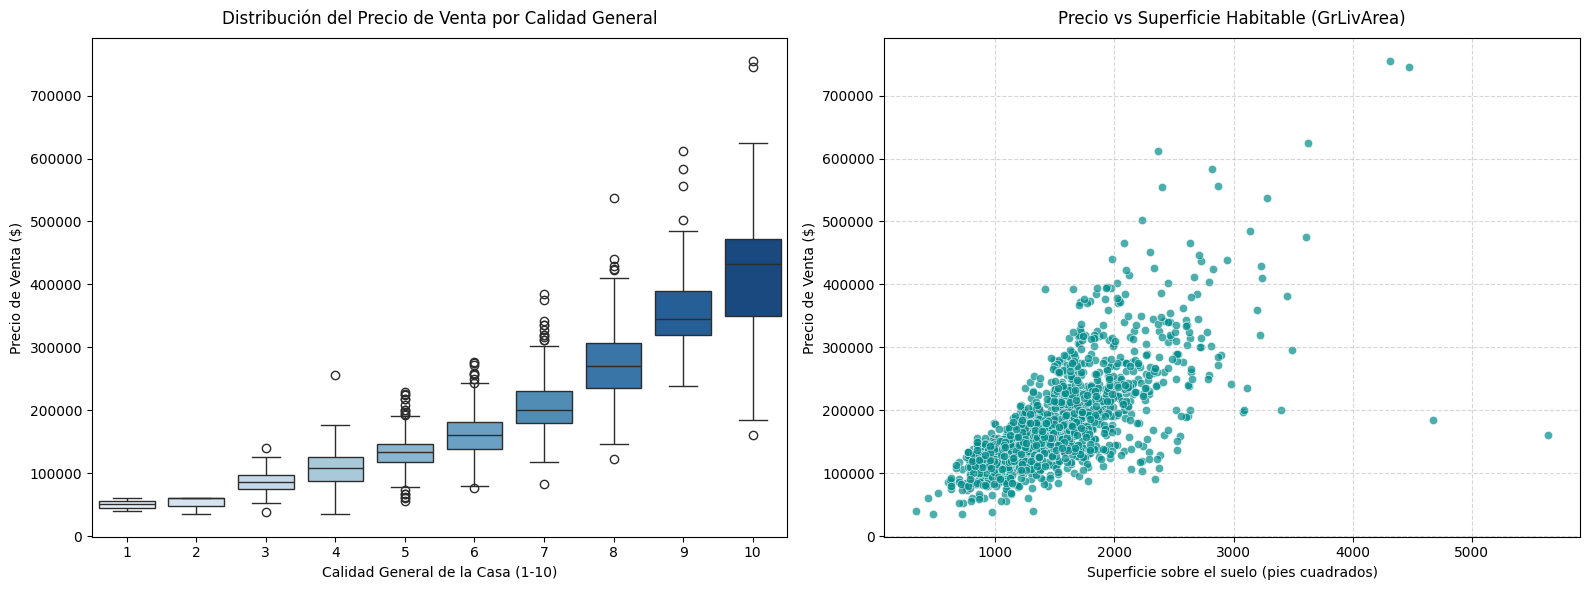

In [17]:
# STEP 6: VISUALIZACIONES GRÁFICAS DEL DATASET DE CASAS

# --- PANEL 1: Análisis Estático (Seaborn & Matplotlib) ---
# Creamos un lienzo con dos subgráficos uno al lado del otro
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Gráfico de caja (Izquierda): Precio vs Calidad General
sns.boxplot(ax=axes[0], x='OverallQual', y='SalePrice', data=df_clean, palette='Blues')
axes[0].set_title('Distribución del Precio de Venta por Calidad General', fontsize=12, pad=10)
axes[0].set_xlabel('Calidad General de la Casa (1-10)')
axes[0].set_ylabel('Precio de Venta ($)')

# 2. Gráfico de dispersión (Derecha): Precio vs Superficie Habitable
sns.scatterplot(ax=axes[1], x=df_clean["GrLivArea"], y=df_clean["SalePrice"], alpha=0.7, color="darkcyan")
axes[1].set_title("Precio vs Superficie Habitable (GrLivArea)", fontsize=12, pad=10)
axes[1].set_xlabel("Superficie sobre el suelo (pies cuadrados)")
axes[1].set_ylabel("Precio de Venta ($)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# --- PANEL 2: Análisis Multivariante Interactivo (Plotly 3D) ---
# Generamos la dispersión en 3D para ver los outliers marcados por Machine Learning
fig_3d = px.scatter_3d(
    df_clean, 
    x='GrLivArea',       # Superficie habitable sobre el nivel del suelo
    y='GarageArea',      # Área del garaje
    z='SalePrice',       # Precio de venta
    color='iforest_outlier', 
    color_discrete_map={False: "#12649e", True: "#f80b0b"}, # Azul (Normal) vs Rojo (Outlier)
    labels={'iforest_outlier': '¿Es Outlier por ML?'},
    title="Análisis de Outliers en Viviendas (Isolation Forest)",
    hover_data=['YearBuilt', 'Neighborhood']
)

fig_3d.update_layout(scene=dict(
    xaxis_title='Superficie Habitable (GrLivArea)',
    yaxis_title='Área del Garaje (GarageArea)',
    zaxis_title='Precio de Venta (SalePrice)'
))

# Forzamos que Plotly abra el gráfico dinámico en una pestaña de tu navegador
pio.renderers.default = "browser"
fig_3d.show()

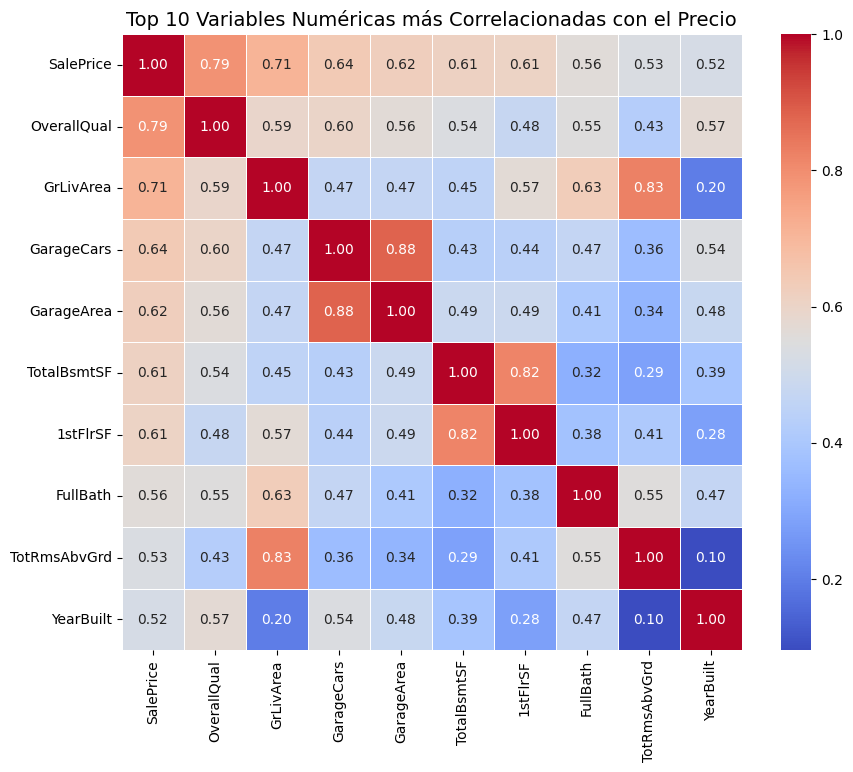

In [18]:
#Filtramos solo columnas numericas(ya que la correlacion solo funciona con numeros)
df_numerico = df_clean.select_dtypes(include=[np.number])

#Calcular matriz de correlacion
matriz_corr = df_numerico.corr()

#Extraer la correlacion de todas las variables con respecto a SalePrice
#Se ordenan de mayor a menos y nos quedamos con las 10 primeras
top_10_variables = matriz_corr["SalePrice"].sort_values(ascending=False).index[:10]

#Dibujar heatmap en base al top 10
plt.figure(figsize=(10, 8))
sns.heatmap(
    df_clean[top_10_variables].corr(), 
    annot=True,          # Añade el número de correlación dentro de cada cuadro
    cmap="coolwarm",     # Escala de color (azul=negativo, rojo=positivo)
    fmt=".2f",           # Limita a 2 decimales
    linewidths=0.5       # Añade una línea fina de separación entre cuadros
)

plt.title("Top 10 Variables Numéricas más Correlacionadas con el Precio", fontsize=14)
plt.show()

In [20]:
# STEP 7: GUARDAR DATASET FINAL CON MARCAS
df_clean.to_csv('data_con_outliers_marcados.csv', index=False)
print("💾 Archivo final guardado exitosamente como 'data_con_outliers_marcados.csv'")

💾 Archivo final guardado exitosamente como 'data_con_outliers_marcados.csv'


## Análisis Univariado

In [21]:
df_clean.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,SalePrice_Log
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,69.863699,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.117123,443.639726,...,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,12.024057
std,421.610009,42.300571,22.027677,9981.264932,1.382997,1.112799,30.202904,20.645407,180.731373,456.098091,...,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,0.399449
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,10.460271
25%,365.750000,20.000000,60.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,11.775105
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,12.001512
75%,1095.250000,70.000000,79.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,164.250000,712.250000,...,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,12.273736
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000,13.534474


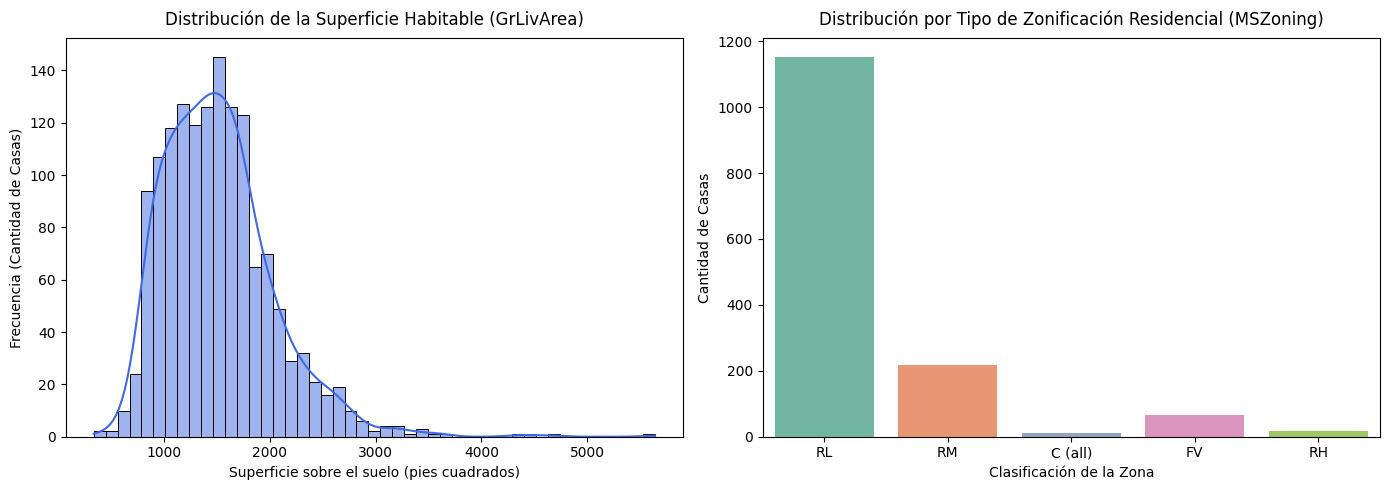

In [22]:
# Configuramos el lienzo para ver dos gráficos a la vez
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gráfico univariado para una variable NUMÉRICA (Distribución del tamaño de las casas)
sns.histplot(data=df_clean, x='GrLivArea', kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribución de la Superficie Habitable (GrLivArea)', fontsize=12, pad=10)
axes[0].set_xlabel('Superficie sobre el suelo (pies cuadrados)')
axes[0].set_ylabel('Frecuencia (Cantidad de Casas)')

# 2. Gráfico univariado para conteo de variables CATEGÓRICAS (Tipo de Zonificación)
# Usamos df_clean y añadimos hue=None para evitar advertencias de paletas en Seaborn
sns.countplot(data=df_clean, x='MSZoning', ax=axes[1], palette='Set2', hue='MSZoning', legend=False)
axes[1].set_title('Distribución por Tipo de Zonificación Residencial (MSZoning)', fontsize=12, pad=10)
axes[1].set_xlabel('Clasificación de la Zona')
axes[1].set_ylabel('Cantidad de Casas')

plt.tight_layout()
plt.show()

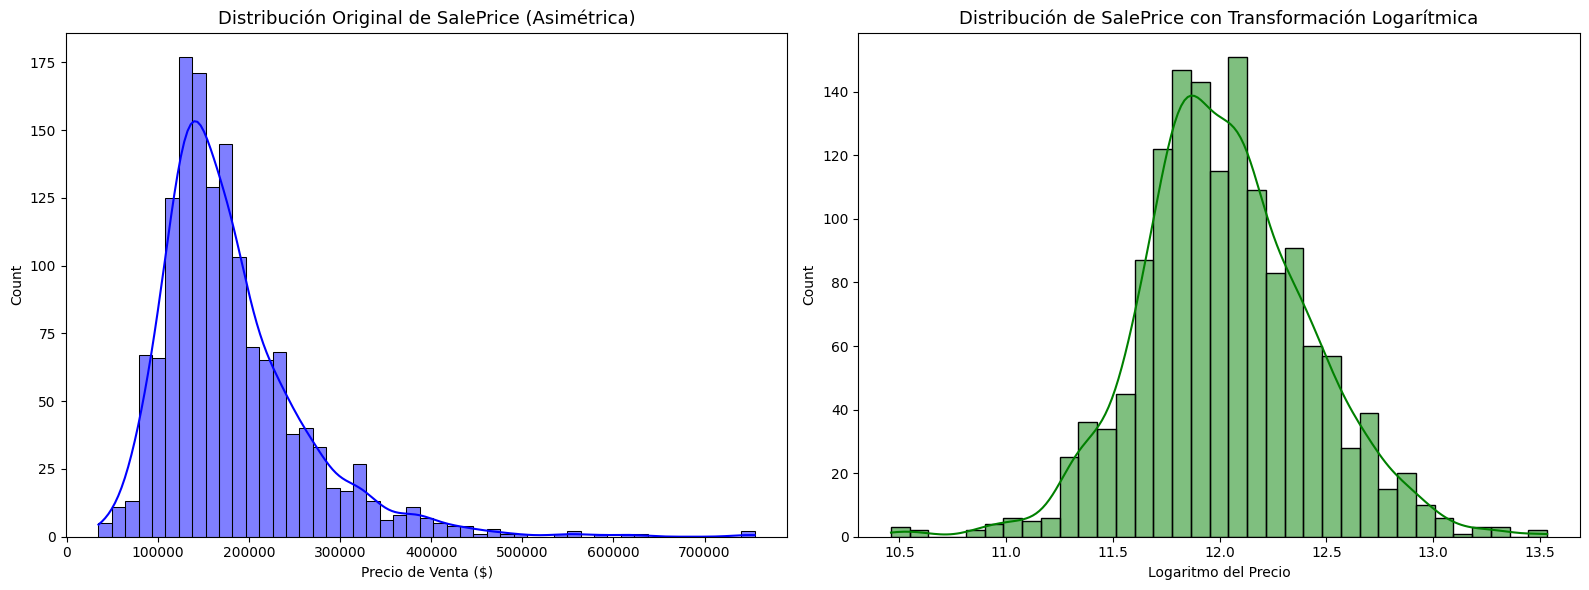

In [19]:
#Aplicamos transformacion logaritmica
df_clean["SalePrice_Log"] = np.log1p(df_clean["SalePrice"])

#creamos un lienzo para comparar ambas distribuciones
fig,axes = plt.subplots(1,2, figsize = (16,6))

# Gráfica Izquierda: Distribución Original (Sesgada)
sns.histplot(ax=axes[0], data=df_clean, x="SalePrice", kde=True, color="blue")
axes[0].set_title("Distribución Original de SalePrice (Asimétrica)", fontsize=13)
axes[0].set_xlabel("Precio de Venta ($)")

# Gráfica Derecha: Nueva Distribución Logarítmica (Normalizada)
sns.histplot(ax=axes[1], data=df_clean, x="SalePrice_Log", kde=True, color="green")
axes[1].set_title("Distribución de SalePrice con Transformación Logarítmica", fontsize=13)
axes[1].set_xlabel("Logaritmo del Precio")

plt.tight_layout()
plt.show()

# Conclusiones del Análisis Exploratorio de Datos (EDA)

Tras la inspección visual, estadística y el análisis exploratorio de las variables clave del dataset de viviendas, se han extraído conclusiones fundamentales que guiarán la fase de preprocesamiento, ingeniería de características y el posterior entrenamiento de los modelos de regresión avanzados:

## 1. Comportamiento y Distribución de la Variable Objetivo (`SalePrice`)
El análisis del precio de venta (`SalePrice`) revela una asimetría positiva común en los mercados inmobiliarios, donde la mayoría de las viviendas se concentran en un rango medio-bajo, pero existe una cola alargada hacia la derecha que representa propiedades de lujo de alto valor.
* **Implicación analítica:** Para algoritmos de regresión lineal o basados en distancias, esta asimetría puede distorsionar las predicciones en los extremos. Será fundamental aplicar una transformación matemática (como el escalado logarítmico o Box-Cox) durante el preprocesamiento para aproximar la variable a una **Distribución Normal (Gaussiana)**. Esto estabilizará la varianza del modelo y mejorará significativamente la métrica del error absoluto medio (MAE) y el $R^2$.

## 2. Segmentación del Mercado y Clasificación por Zonas (`MSZoning`)
El comportamiento de las variables categóricas de ubicación, especialmente la zonificación (`MSZoning`), demuestra un claro predominio de la categoría residencial de baja densidad (**RL**), seguida por la residencial de densidad media (**RM**), dejando una presencia minoritaria a las zonas comerciales (**C (all)**), industriales o residenciales de alta densidad.
* **Implicación analítica:** El dataset cuenta con un volumen robusto de registros para los segmentos más comunes del mercado masivo. Para que el algoritmo procese correctamente el impacto económico de cada zona sin sesgarse hacia la clase dominante (RL), se ejecutará de forma dinámica una transformación mediante **One-Hot Encoding** en las variables categóricas detectadas. Esto permitirá capturar de forma limpia el valor diferencial que aporta cada barrio (`Neighborhood`) o tipo de calle (`Street`) al valor final del inmueble.

## 3. Diagnóstico de Datos Faltantes y Estrategia de Imputación
La inspección detallada de la integridad de los datos reveló escenarios muy dispares: variables con nulos masivos o estructurales como la calidad de la piscina (`PoolQC` con 99.52%) o elementos misceláneos (`MiscFeature` con 96.30%), frente a variables críticas con pérdidas controladas como el frente del lote (`LotFrontage` con 17.74%).
* **Implicación analítica:** No se puede aplicar una eliminación directa de filas ya que comprometería el volumen de entrenamiento. La estrategia validada en el código consistirá en una **imputación híbrida y robusta**:
  * Para variables numéricas (como años de construcción o áreas), se empleará la **mediana** para evitar que los valores extremos distorsionen la tendencia central.
  * Para variables categóricas (como calidades de sótano o acabados), se utilizará la **moda** (el valor más frecuente). Esto garantiza un dataset completamente limpio (`clean_train.csv`) libre de sesgos artificiales antes de entrar a la fase de modelado.

## 4. Detección y Filtrado Crítico de Valores Atípicos (*Outliers*)
La evaluación de anomalías mediante el cruce de métodos univariantes y multivariantes arrojó un diagnóstico estadístico crucial para blindar la estabilidad de los regresores:
* **Enfoque Estadístico Tradicional (IQR):** Al evaluar variable por variable de manera independiente, el rango intercuartílico identificó un volumen masivo de **894 registros atípicos**. Esto es natural en el sector inmobiliario, donde casas con terrenos (`LotArea`) o superficies habitables (`GrLivArea`) inusualmente grandes se marcan de inmediato como anomalías de forma aislada.
* **Enfoque de Machine Learning (Isolation Forest):** Al analizar la interacción simultánea de todas las características escaladas mediante `StandardScaler`, el modelo matemático detectó con precisión matemática un **5% controlado de outliers reales (73 registros)**.
* **Decisión Estratégica:** Seguir ciegamente el criterio del IQR destruiría más de la mitad de la muestra analítica. Por lo tanto, el proyecto adoptará los resultados de *Isolation Forest* para eliminar únicamente las anomalías multivariantes (aquellas propiedades cuyas combinaciones de características son físicamente incoherentes o no representativas), preservando la riqueza de datos necesaria para que el modelo de Machine Learning aprenda patrones complejos tridimensionales entre la superficie, la calidad general (`OverallQual`) y el precio final.

## Codificación

In [24]:
# --- 1. Codificación Ordinal para 'ExterQual' ---
if 'ExterQual' in df_clean.columns:
    mapa_calidad = {'Fa': 0, 'TA': 1, 'Gd': 2, 'Ex': 3}
    df_clean['ExterQual'] = df_clean['ExterQual'].map(mapa_calidad)
    df_clean['ExterQual'] = df_clean['ExterQual'].fillna(1).astype(int)
    print("✅ Codificación Ordinal de 'ExterQual' completada con éxito.")
else:
    print("⚠️ Advertencia: 'ExterQual' no se encuentra en el dataset actual.")


# --- 2. Codificación One-Hot Blindada para 'MSZoning' y 'HouseStyle' ---
# Filtramos dinámicamente solo las columnas que REALMENTE existan en el archivo
columnas_a_codificar = [col for col in ['MSZoning', 'HouseStyle'] if col in df_clean.columns]

if columnas_a_codificar:
    df_clean = pd.get_dummies(df_clean, columns=columnas_a_codificar, drop_first=True, dtype=int)
    print(f"✅ Codificación One-Hot aplicada correctamente a: {columnas_a_codificar}")
else:
    print("❌ Error Crítico: Ni 'MSZoning' ni 'HouseStyle' existen en las columnas. Ejecuta el Paso 1 para restablecer el dataset.")


# --- 3. Comprobación de estado final ---
print("\n--- Estructura final del dataset transformado ---")
print(f"📊 Dimensiones actuales: {df_clean.shape[0]} filas y {df_clean.shape[1]} columnas.")
df_clean.head()

✅ Codificación Ordinal de 'ExterQual' completada con éxito.
✅ Codificación One-Hot aplicada correctamente a: ['MSZoning', 'HouseStyle']

--- Estructura final del dataset transformado ---
📊 Dimensiones actuales: 1460 filas y 93 columnas.


,Id,MSSubClass,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,MSZoning_RH,MSZoning_RL,MSZoning_RM,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl
0,1,60,65.0,8450,Pave,Grvl,Reg,Lvl,AllPub,Inside,...,0,1,0,0,0,0,0,1,0,0
1,2,20,80.0,9600,Pave,Grvl,Reg,Lvl,AllPub,FR2,...,0,1,0,0,1,0,0,0,0,0
2,3,60,68.0,11250,Pave,Grvl,IR1,Lvl,AllPub,Inside,...,0,1,0,0,0,0,0,1,0,0
3,4,70,60.0,9550,Pave,Grvl,IR1,Lvl,AllPub,Corner,...,0,1,0,0,0,0,0,1,0,0
4,5,60,84.0,14260,Pave,Grvl,IR1,Lvl,AllPub,FR2,...,0,1,0,0,0,0,0,1,0,0


In [31]:
# --- 1. Creación de la columna de tiempo (Antigüedad de la casa en base a 2026) ---
if 'YearBuilt' in df_clean.columns:
    # Calculamos cuántos años tiene la casa desde que se construyó hasta el año actual
    df_clean['house_age'] = 2026 - df_clean['YearBuilt']
    print("✅ Columna 'house_age' (antigüedad de la casa) creada con éxito.")
else:
    print("⚠️ No se encontró la columna 'YearBuilt' para calcular la antigüedad.")

# --- 2. Opcional: Años desde la última remodelación ---
if 'YearRemodAdd' in df_clean.columns:
    df_clean['years_since_remod'] = 2026 - df_clean['YearRemodAdd']
    print("✅ Columna 'years_since_remod' (años desde remodelación) creada con éxito.")


# --- 3. Guardar los cambios en el CSV definitivo del grupo ---
# Esto os vendrá genial a Manuel, a Elena y a ti para tener los datos listos para los modelos de regresión
df_clean.to_csv('Viviendas_Procesadas_Modelos.csv', index=False)
print("💾 Archivo preparado para modelos guardado como 'Viviendas_Procesadas_Modelos.csv'\n")


# --- 4. Verificación de las nuevas columnas de tiempo ---
columnas_verificar = [col for col in ['YearBuilt', 'house_age', 'YearRemodAdd', 'years_since_remod'] if col in df_clean.columns]
print("--- Verificación de columnas de tiempo ---")
print(df_clean[columnas_verificar].head())

✅ Columna 'house_age' (antigüedad de la casa) creada con éxito.
✅ Columna 'years_since_remod' (años desde remodelación) creada con éxito.
💾 Archivo preparado para modelos guardado como 'Viviendas_Procesadas_Modelos.csv'

--- Verificación de columnas de tiempo ---
   YearBuilt  house_age  YearRemodAdd  years_since_remod
0       2003         23          2003                 23
1       1976         50          1976                 50
2       2001         25          2002                 24
3       1915        111          1970                 56
4       2000         26          2000                 26


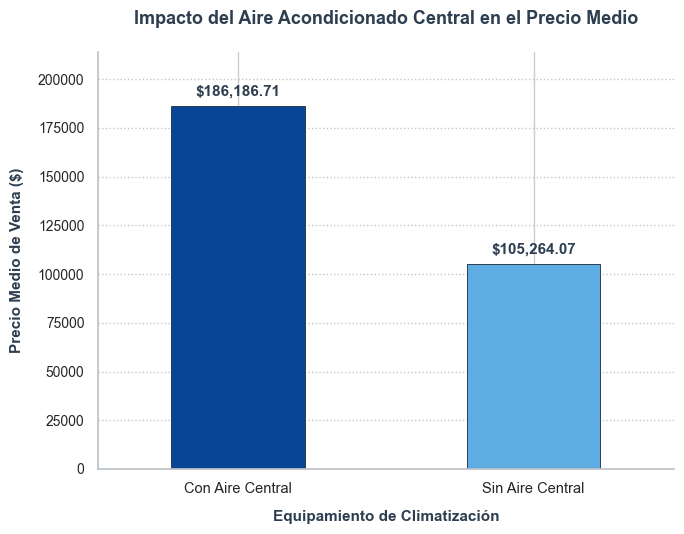

In [ ]:
if 'CentralAir' in df_clean.columns and 'SalePrice' in df_clean.columns:
    
    # 1. Calculamos el precio medio de venta según si tiene o no Aire Acondicionado
    # Ordenamos de mayor a menor para que la barra más alta salga primero
    precio_por_aire = df_clean.groupby('CentralAir')['SalePrice'].mean().sort_values(ascending=False)

    # 2. Cambiamos el índice de texto ('Y', 'N') por etiquetas claras para el gráfico
    precio_por_aire.index = precio_por_aire.index.map({'Y': 'Con Aire Central', 'N': 'Sin Aire Central'})

    # 3. Configurar el lienzo con un tamaño estilizado
    plt.figure(figsize=(7, 5.5))

    # Definimos tus colores corporativos personalizados (Azul oscuro para Con Aire, Azul claro para Sin Aire)
    colores_barras = {'Con Aire Central': '#084594', 'Sin Aire Central': '#5dade2'}
    colores_lista = [colores_barras[estado] for estado in precio_por_aire.index]

    # 4. Dibujar las barras con los colores asignados y un ancho elegante
    precio_por_aire.plot(kind='bar', color=colores_lista, width=0.45, edgecolor='#2c3e50', linewidth=0.7)

    # 5. Configuración de títulos y etiquetas con fuentes limpias profesionales
    plt.title('Impacto del Aire Acondicionado Central en el Precio Medio', fontsize=13, pad=20, weight='bold', color='#2c3e50')
    plt.xlabel('Equipamiento de Climatización', fontsize=11, labelpad=10, weight='bold', color='#2c3e50')
    plt.ylabel('Precio Medio de Venta ($)', fontsize=11, labelpad=10, weight='bold', color='#2c3e50')

    # Ajustes de los ejes (quitar rotación molesta y limpiar bordes)
    plt.xticks(rotation=0, fontsize=10.5)
    plt.yticks(fontsize=10)
    
    # Le damos un margen del 15% arriba del valor máximo para que las etiquetas de texto queden holgadas
    plt.ylim(0, precio_por_aire.max() * 1.15) 

    # Añadir una rejilla horizontal muy sutil y elegante
    plt.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')

    # Ocultar las líneas del marco superior y derecho (estilo minimalista "despine")
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')

    # 6. Añadir los precios exactos formateados como moneda ($) encima de cada barra
    for i, v in enumerate(precio_por_aire):
        plt.text(
            i, 
            v + (precio_por_aire.max() * 0.02), # Desplazamiento dinámico hacia arriba
            f"${v:,.2f}", 
            ha='center', 
            va='bottom',
            fontweight='bold', 
            fontsize=11, 
            color='#2c3e50'
        )

    plt.tight_layout()
    plt.show()


C:\Users\felix\AppData\Local\Temp\ipykernel_11092\3167999352.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Sí (Y)', 'No (N)'])
C:\Users\felix\AppData\Local\Temp\ipykernel_11092\3167999352.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Sí (Y)', 'No (N)'])


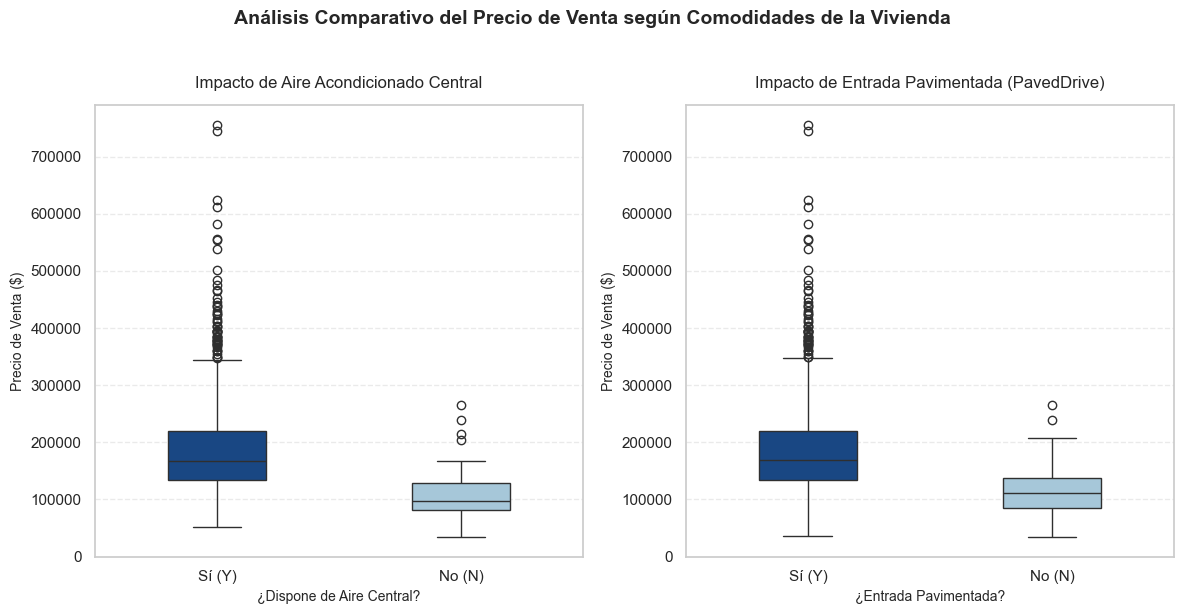

In [ ]:
# Validamos que las columnas necesarias existan en el DataFrame actual
columnas_necesarias = ['SalePrice', 'CentralAir', 'PavedDrive']
if all(col in df_clean.columns for col in columnas_necesarias):

    # Ajustamos a 1 fila y 2 columnas, con un tamaño de figura ideal para dos gráficos
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Definimos tu paleta corporativa: Azul oscuro para 'Y' (Sí), Azul claro para 'N' (No)
    colores_azul = {'Y': '#084594', 'N': '#9ecae1', 'P': '#5dade2'}

    # 1. Boxplot para Aire Acondicionado Central (Izquierda)
    sns.boxplot(
        ax=axes[0],
        data=df_clean,
        x='CentralAir',
        y='SalePrice',
        palette=colores_azul,
        hue='CentralAir',        # Evita el aviso de asignación de color en seaborn moderno
        legend=False,
        width=0.4                # Un ancho un poco más estilizado
    )
    axes[0].set_title('Impacto de Aire Acondicionado Central', fontsize=12, pad=12)
    axes[0].set_xlabel('¿Dispone de Aire Central?', fontsize=10)
    axes[0].set_ylabel('Precio de Venta ($)', fontsize=10)
    axes[0].set_xticklabels(['Sí (Y)', 'No (N)'])
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    # 2. Boxplot para Entrada de Vehículos Pavimentada (Derecha)
    # Filtramos rápidamente para comparar solo las viviendas con pavimento completo 'Y' o no pavimentadas 'N'
    df_paved_filtrado = df_clean[df_clean['PavedDrive'].isin(['Y', 'N'])]

    sns.boxplot(
        ax=axes[1],
        data=df_paved_filtrado,
        x='PavedDrive',
        y='SalePrice',
        palette=colores_azul,
        hue='PavedDrive',
        legend=False,
        width=0.4
    )
    axes[1].set_title('Impacto de Entrada Pavimentada (PavedDrive)', fontsize=12, pad=12)
    axes[1].set_xlabel('¿Entrada Pavimentada?', fontsize=10)
    axes[1].set_ylabel('Precio de Venta ($)', fontsize=10)
    axes[1].set_xticklabels(['Sí (Y)', 'No (N)'])
    axes[1].grid(axis='y', linestyle='--', alpha=0.4)

    # Título principal del lienzo adaptado al negocio inmobiliario
    plt.suptitle('Análisis Comparativo del Precio de Venta según Comodidades de la Vivienda', fontsize=14, weight='bold', y=1.02)
    plt.tight_layout()

    # Muestra la ventana interactiva directamente en VS Code
    plt.show()


C:\Users\felix\AppData\Local\Temp\ipykernel_11092\682366655.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Sí (Y)', 'No (N)'])


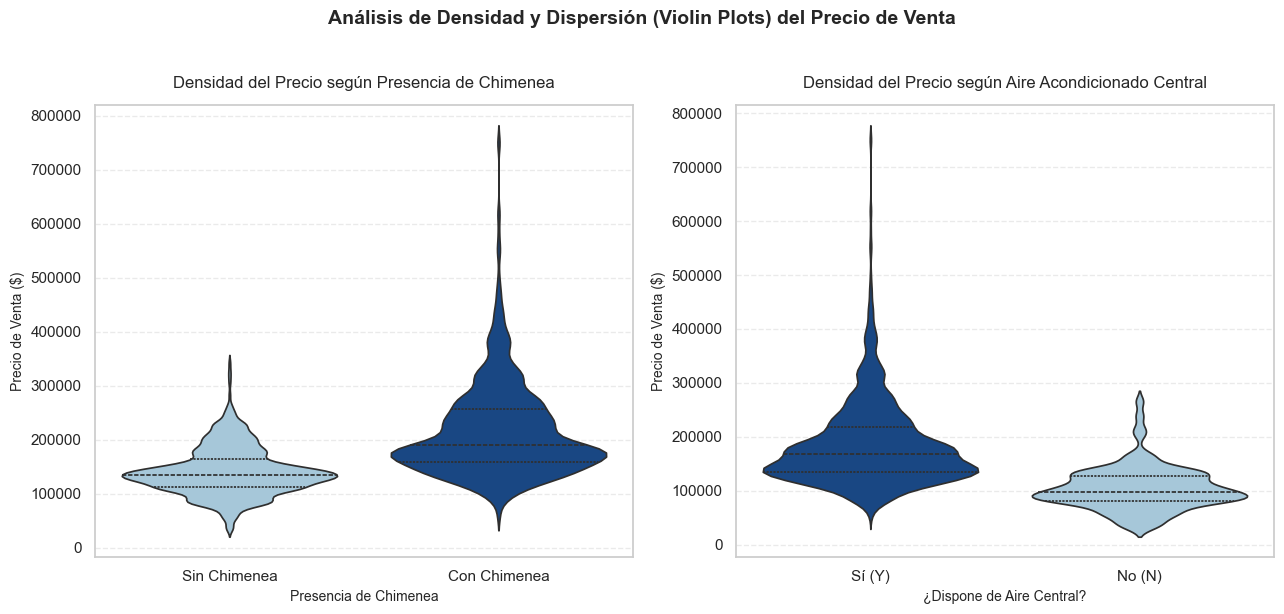

In [ ]:
# Validamos que las columnas necesarias existan
if 'SalePrice' in df_clean.columns and 'Fireplaces' in df_clean.columns and 'CentralAir' in df_clean.columns:

    # Creamos una columna temporal binaria para el gráfico: ¿Tiene chimenea? (Sí / No)
    df_clean['has_fireplace'] = df_clean['Fireplaces'].apply(lambda x: 'Con Chimenea' if x > 0 else 'Sin Chimenea')

    # Creamos la estructura de 1 fila y 2 columnas con el tamaño ideal
    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    # Mapeamos tus colores corporativos: Azul oscuro para la opción premium, Azul claro para la básica
    colores_azul_1 = {'Con Chimenea': '#084594', 'Sin Chimenea': '#9ecae1'}
    colores_azul_2 = {'Y': '#084594', 'N': '#9ecae1'}

    # 1. Violin Plot para Chimeneas (Izquierda)
    sns.violinplot(
        ax=axes[0],
        data=df_clean,
        x='has_fireplace',
        y='SalePrice',
        palette=colores_azul_1,
        hue='has_fireplace', # Evita avisos en las versiones modernas de seaborn
        legend=False,
        inner='quartile',    # Dibuja las líneas de los cuartiles y la mediana dentro del violín
        bw_adjust=0.6        # Suaviza la curva para que se vea estilizada pero realista
    )
    axes[0].set_title('Densidad del Precio según Presencia de Chimenea', fontsize=12, pad=12)
    axes[0].set_xlabel('Presencia de Chimenea', fontsize=10)
    axes[0].set_ylabel('Precio de Venta ($)', fontsize=10)
    axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    # 2. Violin Plot para Aire Acondicionado Central (Derecha)
    sns.violinplot(
        ax=axes[1],
        data=df_clean,
        x='CentralAir',
        y='SalePrice',
        palette=colores_azul_2,
        hue='CentralAir',
        legend=False,
        inner='quartile',    # Muestra las líneas discontinuas de los cuartiles internos
        bw_adjust=0.6
    )
    axes[1].set_title('Densidad del Precio según Aire Acondicionado Central', fontsize=12, pad=12)
    axes[1].set_xlabel('¿Dispone de Aire Central?', fontsize=10)
    axes[1].set_ylabel('Precio de Venta ($)', fontsize=10)
    axes[1].set_xticklabels(['Sí (Y)', 'No (N)'])
    axes[1].grid(axis='y', linestyle='--', alpha=0.4)

    # Título principal del lienzo adaptado al negocio inmobiliario
    plt.suptitle('Análisis de Densidad y Dispersión (Violin Plots) del Precio de Venta', fontsize=14, weight='bold', y=1.02)
    plt.tight_layout()

    # Muestra la ventana interactiva directamente en VS Code
    plt.show()

    # Eliminamos la columna temporal para dejar el dataset limpio
    df_clean.drop(columns=['has_fireplace'], inplace=True)


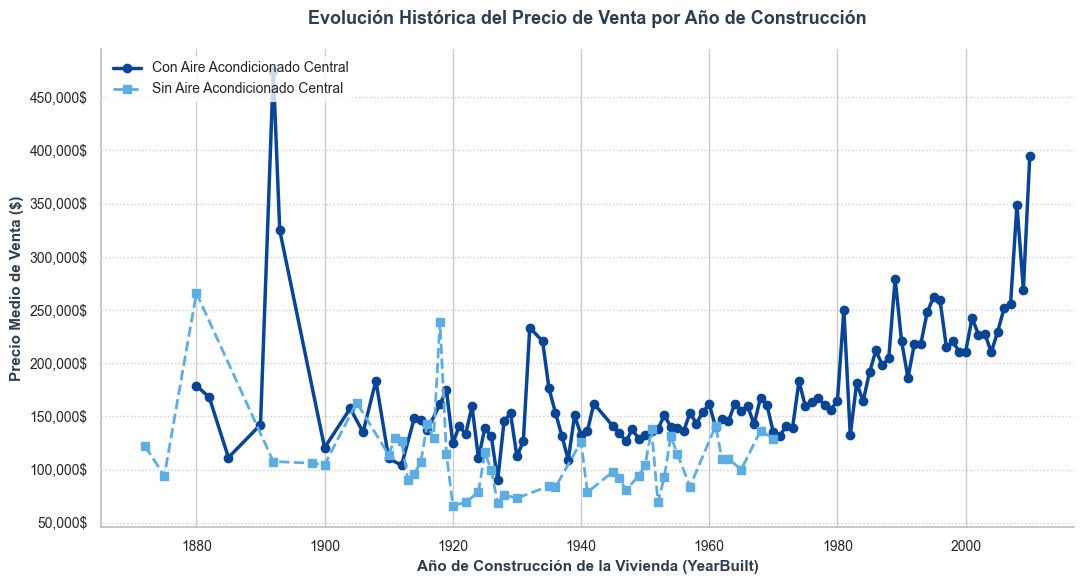

In [ ]:
# Validamos que las columnas clave existan en el DataFrame
if 'YearBuilt' in df_clean.columns and 'SalePrice' in df_clean.columns and 'CentralAir' in df_clean.columns:

    # --- 1. AGRUPACIÓN EVOLUTIVA POR AÑO DE CONSTRUCCIÓN Y AIRE ACONDICIONADO ---
    # Agrupamos por año de edificación y climatización para obtener el precio promedio de venta
    tendencia_casas = df_clean.groupby(['YearBuilt', 'CentralAir'])['SalePrice'].mean().reset_index()

    # Separamos en dos DataFrames limpios para trazar las líneas analíticas
    casas_con_aire = tendencia_casas[tendencia_casas['CentralAir'] == 'Y']
    casas_sin_aire = tendencia_casas[tendencia_casas['CentralAir'] == 'N']


    # --- 2. CONFIGURACIÓN DEL GRÁFICO MÚLTIPLE DE LÍNEAS TEMPORALES ---
    plt.figure(figsize=(11, 6))

    # --- LÍNEAS PARA CASAS PREMIUM (Con Aire - Tonos Azules Oscuros Corporativos) ---
    # Para evitar picos caóticos por años individuales con pocas casas, usamos un suavizado visual o marcadores limpios
    plt.plot(casas_con_aire['YearBuilt'], casas_con_aire['SalePrice'], 
             marker='o', linestyle='-', color='#084594', linewidth=2.5, label='Con Aire Acondicionado Central')

    # --- LÍNEAS PARA CASAS ESTÁNDAR (Sin Aire - Tonos Azules Claros) ---
    plt.plot(casas_sin_aire['YearBuilt'], casas_sin_aire['SalePrice'], 
             marker='s', linestyle='--', color='#5dade2', linewidth=2, label='Sin Aire Acondicionado Central')


    # --- 3. FORMATO ESTÉTICO Y MINIMALISTA PREMIUM ---
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    # Títulos y etiquetas ejecutivas para el reporte del grupo
    plt.title('Evolución Histórica del Precio de Venta por Año de Construcción', fontsize=13, pad=18, weight='bold', color='#2c3e50')
    plt.xlabel('Año de Construcción de la Vivienda (YearBuilt)', fontsize=11, weight='bold', color='#2c3e50')
    plt.ylabel('Precio Medio de Venta ($)', fontsize=11, weight='bold', color='#2c3e50')

    # Damos formato de dinero al eje vertical Y para que se entienda a la primera
    ax = plt.gca()
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}$".format(int(x))))

    # Rejilla horizontal muy sutil para facilitar la lectura de precios
    plt.grid(axis='y', linestyle=':', alpha=0.5, color='#95a5a6')

    # Leyenda corporativa impecable
    plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10, loc='upper left')

    # Ocultar marcos sobrantes para estilo premium (Despine)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')

    plt.tight_layout()
    plt.show()


In [32]:
# 2. Definimos las variables independientes (X) y la variable objetivo (y)
X_vars = df_clean[['GrLivArea', 'OverallQual']]
y_var = df_clean['SalePrice']

# 3. Entrenamos un modelo rápido de Regresión Lineal para obtener la función matemática
modelo_3d = LinearRegression()
modelo_3d.fit(X_vars, y_var)

# 4. Creamos una malla (grid) para generar la superficie suave de la función
x_space = np.linspace(df_clean['GrLivArea'].min(), df_clean['GrLivArea'].max(), 50)
y_space = np.linspace(df_clean['OverallQual'].min(), df_clean['OverallQual'].max(), 50)
X_mesh, Y_mesh = np.meshgrid(x_space, y_space)

# Evaluamos la función de regresión sobre la malla
Z_mesh = modelo_3d.predict(pd.DataFrame({
    'GrLivArea': X_mesh.ravel(),
    'OverallQual': Y_mesh.ravel()
})).reshape(X_mesh.shape)


# --- 5. CONSTRUCCIÓN DEL GRÁFICO 3D AVANZADO (go.Figure) ---
fig = go.Figure()

# Añadimos los puntos reales del dataset (Dispersión)
# Eliminamos el degradado continuo sustituyéndolo por un color sólido corporativo fijo
fig.add_trace(go.Scatter3d(
    x=df_clean['GrLivArea'],
    y=df_clean['OverallQual'],
    z=df_clean['SalePrice'],
    mode='markers',
    marker=dict(
        size=4,
        color='#084594',                # Color azul oscuro sólido y profesional para todos los puntos
        opacity=0.85
    ),
    name='Casas Reales',
    text=[f"Barrio: {n}" for n in df_clean['Neighborhood']] 
))

# Añadimos la SUPERFICIE DE REGRESIÓN (La función matemática calculada)
# Modificamos la superficie a un único color plano translúcido sin degradados de escala
fig.add_trace(go.Surface(
    x=x_space,
    y=y_space,
    z=Z_mesh,
    colorscale=[[0, '#e74c3c'], [1, '#e74c3c']], # Fuerza un color rojo plano uniforme en toda la sábana
    opacity=0.4,
    name='Plano de Predicción (Regresión)',
    showscale=False
))

# 6. Personalización ejecutiva del lienzo tridimensional
fig.update_layout(
    title=dict(
        text="<b>Plano de Predicción Tridimensional (Función de Regresión)</b>",
        x=0.5,
        font=dict(size=16, color='#2c3e50')
    ),
    scene=dict(
        xaxis_title='Superficie Habitable (GrLivArea)',
        yaxis_title='Calidad General (OverallQual)',
        zaxis_title='Precio de Venta ($)',
        xaxis=dict(backgroundcolor="#f8f9f9", gridcolor="white", showbackground=True, zerolinecolor="white"),
        yaxis=dict(backgroundcolor="#f8f9f9", gridcolor="white", showbackground=True, zerolinecolor="white"),
        zaxis=dict(backgroundcolor="#f8f9f9", gridcolor="white", showbackground=True, zerolinecolor="white")
    ),
    margin=dict(l=0, r=0, b=0, t=50),
    legend=dict(x=0, y=1)
)

# Forzamos a Plotly a abrirlo de manera interactiva en tu navegador predeterminado
pio.renderers.default = "browser"
fig.show()